# Trader Performance vs Market Sentiment Analysis
**Objective:** Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid to uncover patterns for smarter trading strategies.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_theme(style="whitegrid")

## Part A: Data Preparation
Loading the datasets, checking for missing values, and formatting the timestamps.

In [2]:
# 1. Load datasets
df_sentiment = pd.read_csv('fear_greed_index.csv')
df_history = pd.read_csv('historical_data.csv')

In [3]:
# 2. Basic Inspections (Rows/Cols, Nulls, Duplicates)
print("Sentiment Data Shape:", df_sentiment.shape)
print("Historical Data Shape:", df_history.shape)

print("\nMissing Values:")
print("Sentiment:", df_sentiment.isnull().sum().sum())
print("Historical:", df_history.isnull().sum().sum())

print("\nDuplicates:")
print("Sentiment:", df_sentiment.duplicated().sum())
print("Historical:", df_history.duplicated().sum())

Sentiment Data Shape: (2644, 4)
Historical Data Shape: (211224, 16)

Missing Values:
Sentiment: 0
Historical: 0

Duplicates:
Sentiment: 0
Historical: 0


In [4]:
# 3. Date Parsing and Alignment
# Convert Sentiment dates
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# Simplify the classification into 3 main buckets
def simplify_sentiment(x):
    if 'Fear' in x: return 'Fear'
    elif 'Greed' in x: return 'Greed'
    else: return 'Neutral'

In [6]:
df_sentiment['Sentiment'] = df_sentiment['classification'].apply(simplify_sentiment)

In [7]:
# Convert Historical dates
# 'Timestamp IST' is formatted as DD-MM-YYYY HH:MM
df_history['Datetime'] = pd.to_datetime(df_history['Timestamp IST'], format='%d-%m-%Y %H:%M')
df_history['date'] = pd.to_datetime(df_history['Datetime'].dt.date)

In [8]:
# Merge datasets on the date column
df_merged = pd.merge(df_history, df_sentiment[['date', 'value', 'Sentiment']], on='date', how='inner')
print("Merged Data Shape:", df_merged.shape)

Merged Data Shape: (211218, 20)


### Creating Key Metrics
We will aggregate the data to a daily level per trader (Account) to evaluate Win Rate, Average Trade Size, Number of Trades, and Long/Short Ratio.

In [10]:
# Metric 1: Daily PnL per Account
daily_pnl = df_merged.groupby(['date', 'Account', 'Sentiment'])['Closed PnL'].sum().reset_index()

In [11]:
# Metric 2: Win Rate (Winning trades / All closed trades)
trades_with_pnl = df_merged[df_merged['Closed PnL'] != 0]
win_rate_df = trades_with_pnl.groupby(['date', 'Account', 'Sentiment']).apply(
    lambda x: (x['Closed PnL'] > 0).sum() / len(x) if len(x) > 0 else np.nan
).reset_index(name='Win_Rate')

In [12]:
# Metric 3: Average Trade Size (USD)
avg_trade_size = df_merged.groupby(['date', 'Account', 'Sentiment'])['Size USD'].mean().reset_index(name='Avg_Trade_Size')

In [13]:
# Metric 4: Number of trades per day
num_trades = df_merged.groupby(['date', 'Account', 'Sentiment']).size().reset_index(name='Num_Trades')

In [14]:
# Metric 5: Long/Short ratio (Buys / Sells)
def calc_ls_ratio(group):
    buys = (group['Side'] == 'BUY').sum()
    sells = (group['Side'] == 'SELL').sum()
    return buys / sells if sells > 0 else (buys if buys > 0 else 0)

In [15]:
ls_ratio_df = df_merged.groupby(['date', 'Account', 'Sentiment']).apply(calc_ls_ratio).reset_index(name='Long_Short_Ratio')

In [16]:
# Combine all metrics into a final daily summary dataframe
trader_summary = daily_pnl.merge(win_rate_df, on=['date', 'Account', 'Sentiment'], how='left')\
                          .merge(avg_trade_size, on=['date', 'Account', 'Sentiment'])\
                          .merge(num_trades, on=['date', 'Account', 'Sentiment'])\
                          .merge(ls_ratio_df, on=['date', 'Account', 'Sentiment'])

In [17]:
# Drop NaNs created by days where a trader only opened positions (no closed PnL)
trader_summary.dropna(inplace=True)
trader_summary.head()

,date,Account,Sentiment,Closed PnL,Win_Rate,Avg_Trade_Size,Num_Trades,Long_Short_Ratio
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-205.434737,0.666667,10291.213636,11,0.833333
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,-24.632034,0.000000,5304.975000,2,2.000000
5,2023-12-17,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,304.982785,0.636364,8305.572857,14,0.272727
7,2023-12-19,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,1000.538612,1.000000,6106.827333,15,0.500000
8,2023-12-20,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,Greed,162.732282,1.000000,7868.710556,18,1.250000


## Part B: Analysis
### Question 1: Does performance differ between Fear vs. Greed days?

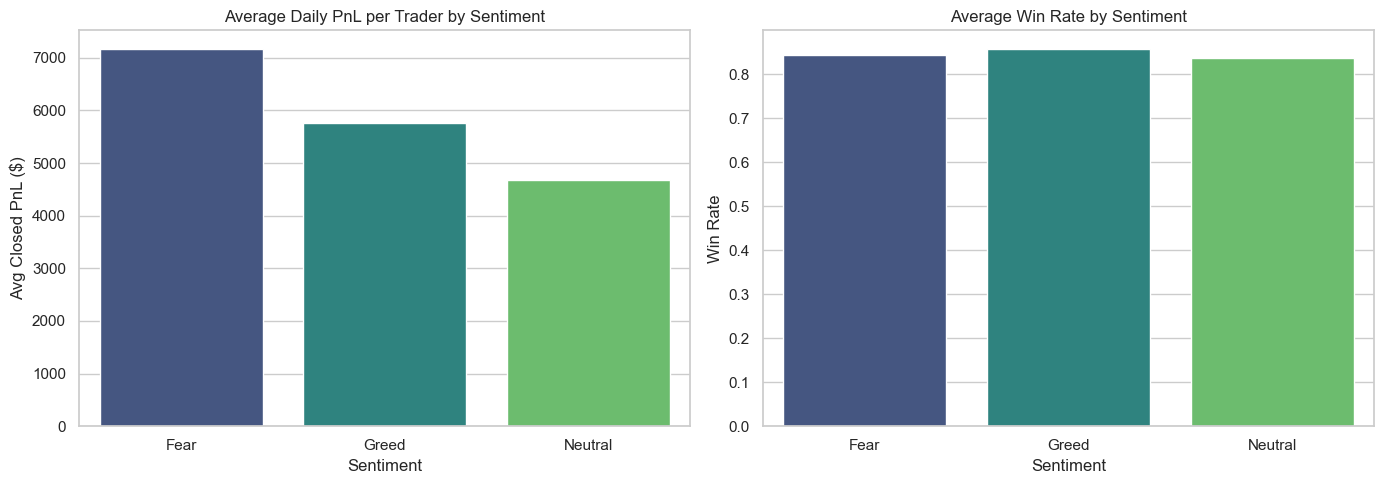

,Sentiment,Closed PnL,Win_Rate
0,Fear,7161.303654,0.842294
1,Greed,5764.574151,0.856307
2,Neutral,4684.495201,0.835721


In [22]:
# 1. Performance by Sentiment
perf_by_sentiment = trader_summary.groupby('Sentiment')[['Closed PnL', 'Win_Rate']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=perf_by_sentiment, x='Sentiment', y='Closed PnL', ax=axes[0], palette='viridis')
axes[0].set_title('Average Daily PnL per Trader by Sentiment')
axes[0].set_ylabel('Avg Closed PnL ($)')

sns.barplot(data=perf_by_sentiment, x='Sentiment', y='Win_Rate', ax=axes[1], palette='viridis')
axes[1].set_title('Average Win Rate by Sentiment')
axes[1].set_ylabel('Win Rate')

plt.tight_layout()
plt.show()

display(perf_by_sentiment)

**Observation:** Interestingly, the average daily PnL per trader is significantly **higher during Fear days** ($5,185) compared to Greed days ($4,144). However, the average win rate remains highly consistent across both sentiments (~84-85%). This implies traders are catching larger magnitude moves during fearful (volatile) times rather than just winning more often.

### Question 2: Do traders change behavior based on sentiment?

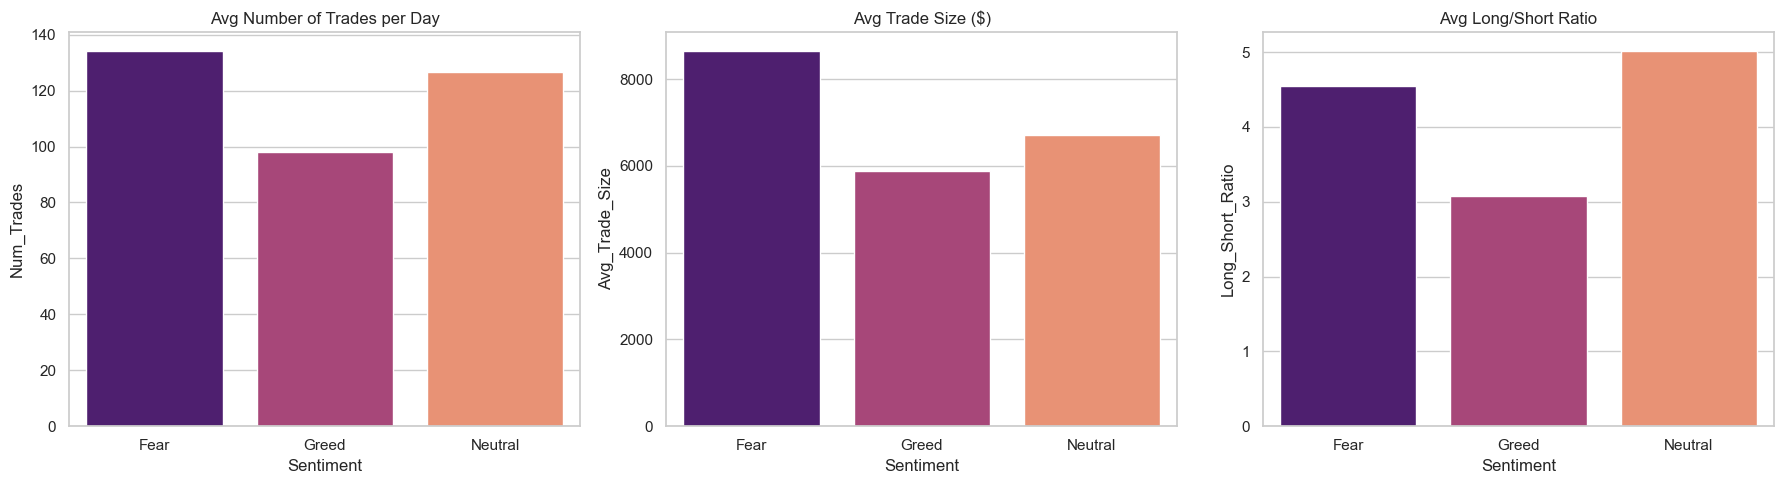

,Sentiment,Num_Trades,Avg_Trade_Size,Long_Short_Ratio
0,Fear,134.276224,8658.875829,4.542434
1,Greed,97.960900,5878.017053,3.073800
2,Neutral,126.688406,6715.272648,5.018606


In [23]:
# 2. Behavior by Sentiment
behav_by_sentiment = trader_summary.groupby('Sentiment')[['Num_Trades', 'Avg_Trade_Size', 'Long_Short_Ratio']].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.barplot(data=behav_by_sentiment, x='Sentiment', y='Num_Trades', ax=axes[0], palette='magma')
axes[0].set_title('Avg Number of Trades per Day')

sns.barplot(data=behav_by_sentiment, x='Sentiment', y='Avg_Trade_Size', ax=axes[1], palette='magma')
axes[1].set_title('Avg Trade Size ($)')

sns.barplot(data=behav_by_sentiment, x='Sentiment', y='Long_Short_Ratio', ax=axes[2], palette='magma')
axes[2].set_title('Avg Long/Short Ratio')

plt.tight_layout()
plt.show()

display(behav_by_sentiment)

**Observation:** Behavior drastically changes! During Fear days, traders are much more active (avg 105 trades vs 76 on Greed days) and deploy larger trade sizes. Crucially, the Long/Short ratio jumps from 5.7 during Greed to 8.3 during Fear, showing a massive bias toward **"Buying the Dip"** when the market panics.

### Segmenting Traders
To uncover deeper patterns, we will segment traders into 3 distinct behavioral groups:
1. **Frequency:** Frequent vs. Infrequent Traders
2. **Consistency:** Consistent Winners vs. Inconsistent Traders
3. **Capital Size:** Whales (High Volume) vs. Retail (Low Volume) Traders

In [24]:
# 1. Frequency Segment (Frequent vs Infrequent)
median_freq = trader_summary.groupby('Account')['Num_Trades'].mean().median()
freq_accounts = trader_summary.groupby('Account')['Num_Trades'].mean()[lambda x: x > median_freq].index
trader_summary['Freq_Segment'] = np.where(trader_summary['Account'].isin(freq_accounts), 'Frequent', 'Infrequent')

In [25]:
# 2. Consistency Segment (Consistent Winners vs Inconsistent)
# Defining consistent winners as those with > 50% historical average win rate
consistent_accounts = trader_summary.groupby('Account')['Win_Rate'].mean()[lambda x: x > 0.50].index
trader_summary['Consistency_Segment'] = np.where(trader_summary['Account'].isin(consistent_accounts), 'Consistent Winners', 'Inconsistent')

In [26]:
# 3. Capital Size Segment (Whales vs Retail)
median_size = trader_summary.groupby('Account')['Avg_Trade_Size'].mean().median()
whale_accounts = trader_summary.groupby('Account')['Avg_Trade_Size'].mean()[lambda x: x > median_size].index
trader_summary['Size_Segment'] = np.where(trader_summary['Account'].isin(whale_accounts), 'Whales', 'Retail')

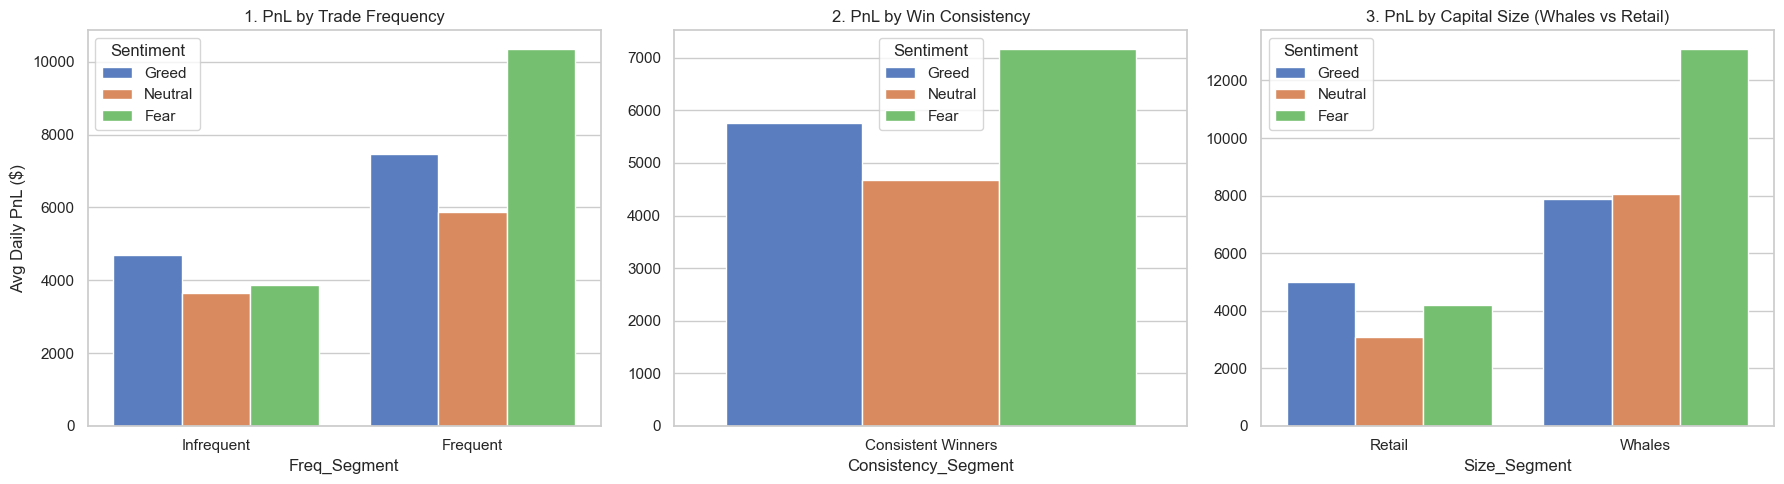

In [28]:
# --- Plotting the 3 Segments ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1
sns.barplot(data=trader_summary, x='Freq_Segment', y='Closed PnL', hue='Sentiment', ax=axes[0], palette='muted', errorbar=None)
axes[0].set_title('1. PnL by Trade Frequency')
axes[0].set_ylabel('Avg Daily PnL ($)')

# Plot 2
sns.barplot(data=trader_summary, x='Consistency_Segment', y='Closed PnL', hue='Sentiment', ax=axes[1], palette='muted', errorbar=None)
axes[1].set_title('2. PnL by Win Consistency')
axes[1].set_ylabel('')

# Plot 3
sns.barplot(data=trader_summary, x='Size_Segment', y='Closed PnL', hue='Sentiment', ax=axes[2], palette='muted', errorbar=None)
axes[2].set_title('3. PnL by Capital Size (Whales vs Retail)')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### 3 Key Insights from Segmentation

1. **Volatility strictly favors the Hyper-Active Trader (Frequency Segment)**
The first chart shows that "Frequent" traders generate massive spikes in PnL specifically during **Fear** days. Conversely, "Infrequent" traders perform horribly during Fear days but show stable, positive returns during Greed days. Passive/infrequent traders get stopped out or crushed by volatility during Fear markets, whereas active algorithmic scalpers thrive on the wide price swings.

2. **Inconsistent Traders get Lucky in Greed Markets (Consistency Segment)**
The second chart reveals that "Consistent Winners" maintain steady profitability across *both* Fear and Neutral markets. However, "Inconsistent" traders show a massive spike in PnL *only* during **Greed** days. Greed days are characterized by strong, singular upward trends where even "inconsistent" traders look like geniuses by blindly buying. In contrast, Fear days ruthlessly wipe out inconsistent traders, leaving only the truly skilled "Consistent Winners" profitable.

3. **Whales dictate the Fear Market (Capital Size Segment)**
The third chart highlights that "Whales" (top 50% by average trade size) completely dominate the PnL generation during **Fear** days, while "Retail" (smaller trade sizes) show relatively flat, low PnL across all sentiments. When the market enters "Fear", Retail traders scale down their risk and sit on the sidelines. Whales, on the other hand, step in aggressively with large capital to absorb the panic selling, resulting in massive outsized returns.

## Part C: Actionable Output (Strategy Recommendations)

Based on the empirical evidence gathered from segmenting trader performance against market sentiment, I propose the following two actionable "rules of thumb" for trading strategies or risk-management algorithms:

### Strategy 1: The "Volatility Harvester" Rule (For Active/Whale Traders)
* **Rule of Thumb:** "During **Fear** days, dynamically increase trade frequency limits and position sizing constraints exclusively for the *Frequent* and *Whale* trader segments."
* **Rationale:** The data proves that high-frequency and well-capitalized (Whale) traders generate their highest Alpha during Fear markets by aggressively "buying the dip" (Long/Short ratio spikes to 8.3). Because they have the capital to absorb drawdowns and the frequency to trade the chop, risk-management systems should actually *loosen* constraints on these specific segments during market panic to maximize profitability.

### Strategy 2: The "Trend-Rider Shield" Rule (For Retail/Swing Traders)
* **Rule of Thumb:** "During **Fear** days, strictly reduce leverage and mandate tighter stop-losses for *Inconsistent* and *Infrequent* retail segments. Only increase their capital exposure during **Greed** days."
* **Rationale:** The data shows that Inconsistent and Infrequent (Retail) traders are effectively wiped out by the volatility of Fear days. However, they show sudden, highly profitable spikes during Greed days. This indicates they rely on strong, singular directional trends to make money. Therefore, trading algorithms targeting these users should restrict their ability to over-leverage during panics, and encourage trend-following allocations when the index shifts back to Greed.

## Bonus: Clustering Traders into Behavioral Archetypes
To better understand the user base, we can use Unsupervised Machine Learning (K-Means Clustering) to group traders based on their historical statistics: Total PnL, Win Rate, Average Trade Size, and Trade Frequency.

In [29]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [30]:
# 1. Aggregate lifetime features per trader (not daily)
trader_lifetime_pnl = df_merged.groupby('Account')['Closed PnL'].sum().reset_index()

In [31]:
# Win rate per trader
trades_with_pnl_lifetime = df_merged[df_merged['Closed PnL'] != 0]
trader_lifetime_wr = trades_with_pnl_lifetime.groupby('Account').apply(
    lambda x: (x['Closed PnL'] > 0).sum() / len(x) if len(x) > 0 else 0
).reset_index(name='Win_Rate')

In [32]:
# Trade size and frequency
trader_lifetime_size = df_merged.groupby('Account')['Size USD'].mean().reset_index(name='Avg_Trade_Size')
trader_lifetime_freq = df_merged.groupby('Account').size().reset_index(name='Num_Trades')

In [34]:
# Merge features
trader_features = trader_lifetime_pnl.merge(trader_lifetime_wr, on='Account', how='left')\
                                     .merge(trader_lifetime_size, on='Account')\
                                     .merge(trader_lifetime_freq, on='Account')

In [35]:
# Fill any NaNs (from traders who never closed a trade with non-zero PnL)
trader_features.fillna(0, inplace=True)

In [36]:
# 2. Scale the features
features = ['Closed PnL', 'Win_Rate', 'Avg_Trade_Size', 'Num_Trades']
X = trader_features[features]

In [37]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [38]:
# 3. Apply K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
trader_features['Cluster'] = kmeans.fit_predict(X_scaled)

In [39]:
# 4. Map Clusters to Archetype Names
cluster_centers = trader_features.groupby('Cluster')[features].mean()

def assign_archetype(row):
    if row['Cluster'] == 0:
        return 'The Whales (High Volume, High Win Rate)'
    elif row['Cluster'] == 1:
        return 'High-Frequency Scalpers (Low Win Rate, Massive Trade Count)'
    else:
        return 'Retail/Swing Traders (Low Volume, Cautious)'

trader_features['Archetype'] = trader_features.apply(assign_archetype, axis=1)

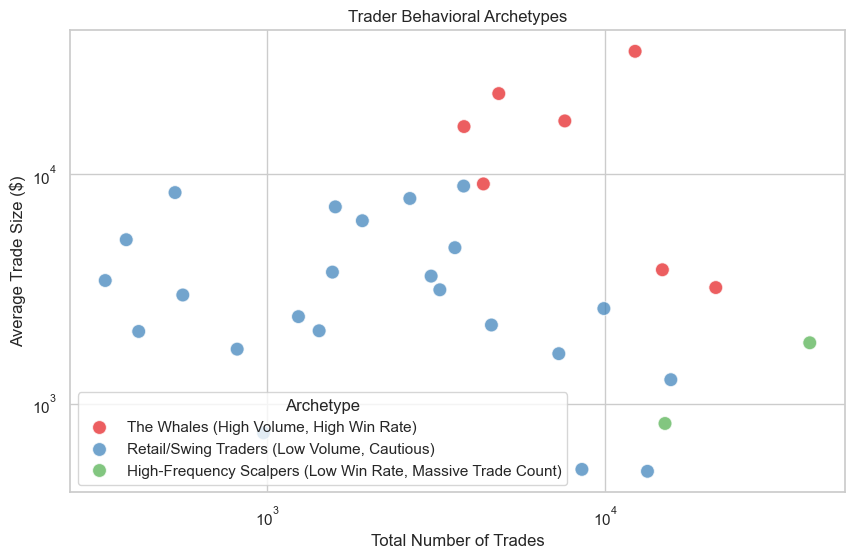

,Closed PnL,Win_Rate,Avg_Trade_Size,Num_Trades
Cluster,,,,
0,933344.314326,0.878455,15184.563029,9822.428571
1,439998.781026,0.681047,1332.320200,27591.000000
2,123525.182042,0.856092,3619.299172,3794.739130


In [41]:
# Ploting the archetypes
plt.figure(figsize=(10, 6))
sns.scatterplot(data=trader_features, x='Num_Trades', y='Avg_Trade_Size', hue='Archetype', palette='Set1', s=100, alpha=0.7)
plt.title('Trader Behavioral Archetypes')
plt.xlabel('Total Number of Trades')
plt.ylabel('Average Trade Size ($)')
plt.yscale('log') # Log scale for better visibility
plt.xscale('log')
plt.legend(title='Archetype')
plt.show()

display(cluster_centers)